In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
cd /content/drive/MyDrive/Machine learning 2024/Notebooks - ANN - DNN/8.Xnee X Ray classification

/content/drive/MyDrive/Machine learning 2024/Notebooks - ANN - DNN/8.Xnee X Ray classification


In [5]:
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [6]:
# Necessary Dependencies
import numpy as np
import pandas as pd
!pip install utils
from utils import *
from glob import glob
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from itertools import chain
from datetime import datetime
import statistics
from tqdm import tqdm
import tensorflow as tf
# DenseNet Dependencies
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.activations import sigmoid
from tensorflow.keras.layers import Dense,Conv2D, Flatten, Dropout, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.metrics import Accuracy, Precision, Recall, AUC, BinaryAccuracy, FalsePositives, FalseNegatives, TruePositives, TrueNegatives
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.applications import DenseNet121, DenseNet169, DenseNet201, VGG16, ResNet50
from keras import backend as K
from tensorflow.keras import Sequential
import keras
import matplotlib
from sklearn.metrics import roc_curve, auc, roc_auc_score
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, LearningRateScheduler
from sklearn.metrics import roc_curve, auc
print('Started')

  Preparing metadata (setup.py) ... done
  Created wheel for utils: filename=utils-1.0.2-py2.py3-none-any.whl size=13905 sha256=4d353ef980b998283f3888e7dae1f0da98f05cce057a76d4127806e306c25584
  Stored in directory: /root/.cache/pip/wheels/b8/39/f5/9d0ca31dba85773ececf0a7f5469f18810e1c8a8ed9da28ca7
Successfully built utils
Started


In [1]:
!pip install install split-folders

ERROR: Could not find a version that satisfies the requirement install (from versions: none)
ERROR: No matching distribution found for install


In [ ]:
import splitfolders
#splitfolders.ratio('Knee X-ray Images', output="New_Dataset", seed=1345, ratio=(.8, 0.1,0.1))

Copying files: 3461 files [00:02, 1367.46 files/s]


In [7]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
"New_Dataset/train",
seed=123,
image_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=64
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
"New_Dataset/test",
seed=123,
image_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=64,
    shuffle=False
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
"New_Dataset/val",
seed=123,
image_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=64
)

Found 2767 files belonging to 5 classes.
Found 347 files belonging to 5 classes.
Found 342 files belonging to 5 classes.


In [ ]:
y_true = np.concatenate([y for x, y in test_ds], axis=0)

In [ ]:
y_true

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,

In [ ]:
# Hyperparameters
IMG_IND=128
IMG_SHAPE = (IMG_IND,IMG_IND,3)
BATCH_SIZE = 32

In [ ]:
def get_callbacks(model_name):
    callbacks =[]

    # Change the file extension to '.keras'
    checkpoint = tf.keras.callbacks.ModelCheckpoint(filepath=f'model.{model_name}.keras', verbose=1, monitor='val_loss',mode='min',save_best_only=True)
    callbacks.append(checkpoint)
    anne = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=2, min_lr=0.0000001,min_delta=0.00001,mode='auto')
    callbacks.append(anne)
    earlystop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)
    callbacks.append(earlystop)

    return callbacks

## Xception Model

In [ ]:
#  Apply DenseNet121 on train df and val_df

base_model = tf.keras.applications.Xception(
    weights='imagenet',
    input_shape=IMG_SHAPE,
    include_top=False
)

base_model.trainable = True

# Add classification head
model = tf.keras.Sequential([
  base_model,
  tf.keras.layers.GlobalAveragePooling2D(),
  tf.keras.layers.Dense(5, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

epochs = 50
callbacks = get_callbacks('Xception')
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  callbacks=callbacks
)


Epoch 1/50
44/44 [==============================] - ETA: 0s - loss: 0.8339 - accuracy: 0.6773
Epoch 1: val_loss improved from inf to 3.60275, saving model to model.Xception.keras
44/44 [==============================] - 22s 277ms/step - loss: 0.8339 - accuracy: 0.6773 - val_loss: 3.6027 - val_accuracy: 0.3246 - lr: 0.0010
Epoch 2/50
44/44 [==============================] - ETA: 0s - loss: 0.3387 - accuracy: 0.8833
Epoch 2: val_loss improved from 3.60275 to 1.50709, saving model to model.Xception.keras
44/44 [==============================] - 11s 245ms/step - loss: 0.3387 - accuracy: 0.8833 - val_loss: 1.5071 - val_accuracy: 0.6374 - lr: 0.0010
Epoch 3/50
44/44 [==============================] - ETA: 0s - loss: 0.2339 - accuracy: 0.9241
Epoch 3: val_loss improved from 1.50709 to 0.98580, saving model to model.Xception.keras
44/44 [==============================] - 11s 247ms/step - loss: 0.2339 - accuracy: 0.9241 - val_loss: 0.9858 - val_accuracy: 0.7193 - lr: 0.0010
Epoch 4/50
44/44 [==

44/44 [==============================] - 11s 243ms/step - loss: 0.0077 - accuracy: 0.9960 - val_loss: 0.1913 - val_accuracy: 0.9678 - lr: 2.5000e-04
Epoch 28/50
44/44 [==============================] - ETA: 0s - loss: 0.0076 - accuracy: 0.9964
Epoch 28: val_loss did not improve from 0.16041

Epoch 28: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
44/44 [==============================] - 11s 243ms/step - loss: 0.0076 - accuracy: 0.9964 - val_loss: 0.1849 - val_accuracy: 0.9591 - lr: 2.5000e-04


In [ ]:
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 xception (Functional)       (None, 4, 4, 2048)        20861480  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 5)                 10245     
                                                                 
Total params: 20,871,725
Trainable params: 20,817,197
Non-trainable params: 54,528
_________________________________________________________________
None


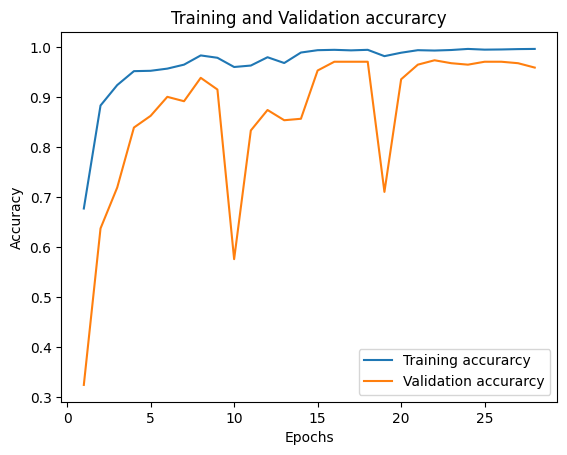

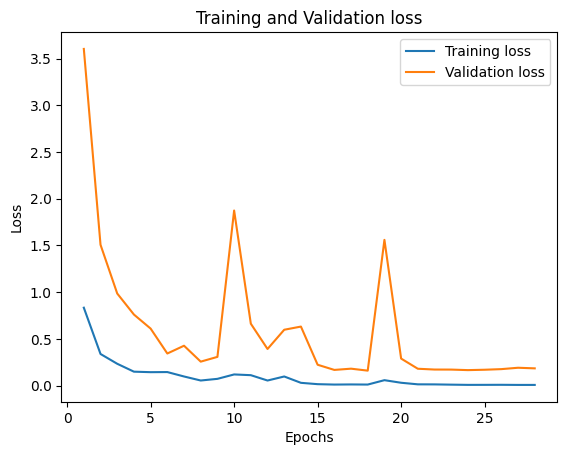

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

#Train and validation accuracy
plt.plot(epochs, acc, label='Training accurarcy')
plt.plot(epochs, val_acc, label='Validation accurarcy')
plt.title('Training and Validation accurarcy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.figure()
#Train and validation loss
plt.plot(epochs, loss,  label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# load the DenseNet121 model

model = tf.keras.models.load_model('model.Xception.keras')


In [ ]:
# Print the classiifcation report

from sklearn.metrics import classification_report
y_pred = model.predict(test_ds)
predicted_categories = np.argmax(y_pred, axis=1)
true_categories = y_true
print(classification_report(true_categories, predicted_categories, digits=4))


6/6 [==============================] - 1s 134ms/step
              precision    recall  f1-score   support

           0     0.9167    0.8462    0.8800        52
           1     0.9208    0.9588    0.9394        97
           2     1.0000    1.0000    1.0000        70
           3     1.0000    1.0000    1.0000        66
           4     1.0000    1.0000    1.0000        62

    accuracy                         0.9654       347
   macro avg     0.9675    0.9610    0.9639       347
weighted avg     0.9654    0.9654    0.9651       347



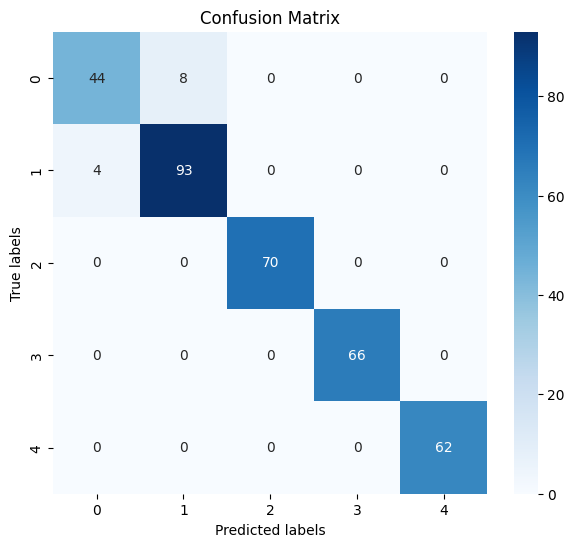

In [ ]:
#  draw the confusion matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get the confusion matrix
cm = confusion_matrix(true_categories, predicted_categories)

# Plot the confusion matrix
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues') #xticklabels=target_names, yticklabels=target_names
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()


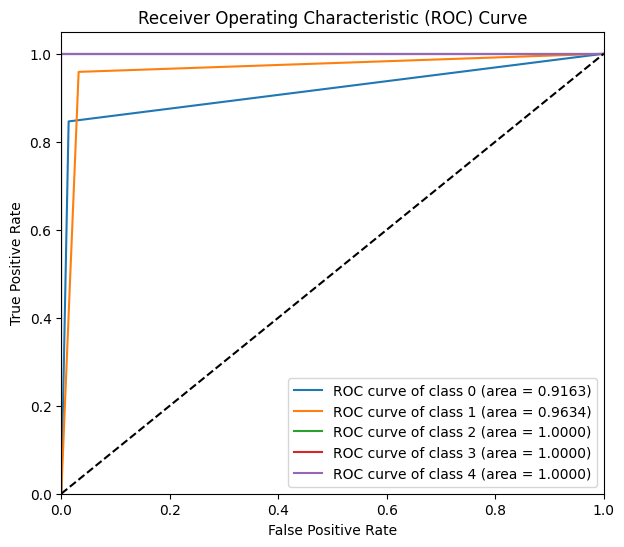

In [ ]:
#  Draw the ROC curve and auc for classes with target names

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the true labels
y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
y_pred_bin = label_binarize(predicted_categories, classes=np.unique(y_true))
n_classes = y_true_bin.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure(figsize=(7, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.4f})'
                               .format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
